<a href="https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-14-self-attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 14. Self-Attention

**Book:** *The Mathematics of Natural Language Processing*  
**Chapter:** 14 — Self-Attention  
**Repository:** [https://github.com/wanghemath/Book-MathNLP](https://github.com/wanghemath/Book-MathNLP)

## Lab purpose

In Chapter 13, attention was introduced as a map from queries, keys, and values to weighted averages. In this lab, we study **self-attention**, where all queries, keys, and values come from the same input sequence.

The goal is not to use a large Transformer library. The goal is to understand the matrix operations behind a self-attention layer by writing them from scratch.

By the end of this lab, you should be able to:

1. represent a sentence as a token matrix $X$;
2. construct $Q=XW_Q$, $K=XW_K$, and $V=XW_V$;
3. compute single-head self-attention from scratch;
4. explain contextual token embeddings;
5. test permutation equivariance without positional encodings;
6. add positional encodings and see why word order matters;
7. build padding and causal masks;
8. implement a simple multi-head self-attention block;
9. measure attention entropy and discuss sharp versus diffuse attention;
10. explain why self-attention has quadratic cost in sequence length.

This notebook is designed for independent study. Read the mathematical explanations before running the code cells.

## 0. Mathematical background

Let a sequence have $T$ tokens. After token embedding and optional positional encoding, we represent the sequence by a matrix

$$
X \in R^{T \times d_{\text{model}}}.
$$

Each row of $X$ is one token-position representation. A self-attention head learns three projection matrices:

$$
W_Q \in R^{d_{\text{model}} \times d_k}, \qquad
W_K \in R^{d_{\text{model}} \times d_k}, \qquad
W_V \in R^{d_{\text{model}} \times d_v}.
$$

The query, key, and value matrices are

$$
Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V.
$$

The score matrix is

$$
S = \frac{QK^T}{\sqrt{d_k}} \in R^{T \times T}.
$$

The row-wise softmax converts each row of $S$ into a probability distribution:

$$
A = \operatorname{softmax}_{\text{row}}(S).
$$

Finally, the output is

$$
Z = AV \in R^{T \times d_v}.
$$

The $i$th output row $z_i$ is a weighted average of all value vectors. The weights are in row $i$ of the attention matrix $A$.

**Interpretation.** The row $A_{i,:}$ tells us which token positions position $i$ uses to construct its new contextual representation.

## 1. Setup

We use only NumPy, pandas, and matplotlib. This keeps the mathematical operations visible and makes the notebook easy to run in Google Colab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(7243)

## 2. Stable row-wise softmax

Self-attention uses a softmax independently on each row of the score matrix. For numerical stability, subtract the maximum value in each row before applying the exponential.

For a row vector $s$, the softmax is

$$
\operatorname{softmax}(s)_j = rac{\exp(s_j)}{\sum_{\ell}\exp(s_{\ell})}.
$$

Subtracting the same constant from every entry of a row does not change the softmax probabilities.

In [2]:
def row_softmax(S):
    """Stable row-wise softmax for a 2D NumPy array."""
    S = np.asarray(S, dtype=float)
    S_shifted = S - S.max(axis=1, keepdims=True)
    E = np.exp(S_shifted)
    return E / E.sum(axis=1, keepdims=True)

# Test on ordinary and very large scores.
S_test = np.array([
    [1.0, 2.0, 3.0],
    [1000.0, 1001.0, 1002.0]
])
A_test = row_softmax(S_test)
print(A_test)
print("Row sums:", A_test.sum(axis=1))

[[0.09  0.245 0.665]
 [0.09  0.245 0.665]]
Row sums: [1. 1.]


### Checkpoint

Every row of the attention matrix must sum to $1$. This is why each row can be interpreted as a probability distribution over token positions.

## 3. A tiny token matrix

We begin with a small sentence. Instead of downloading a corpus, we define a small vocabulary and a hand-designed embedding matrix. This makes the examples interpretable.

In a real model, the embedding matrix is learned. Here the columns are simple semantic features:

1. article-like feature;
2. noun/entity feature;
3. action/verb feature;
4. modifier/context feature;
5. object/topic feature.

In [3]:
vocab = ["the", "student", "reads", "book", "carefully", "teacher", "writes", "notes"]
token_to_id = {w: i for i, w in enumerate(vocab)}

E = np.array([
    [1.00, 0.05, 0.00, 0.00, 0.00],  # the
    [0.05, 1.00, 0.05, 0.00, 0.10],  # student
    [0.00, 0.05, 1.00, 0.15, 0.10],  # reads
    [0.00, 0.20, 0.05, 0.05, 1.00],  # book
    [0.00, 0.05, 0.15, 1.00, 0.10],  # carefully
    [0.05, 1.00, 0.05, 0.00, 0.15],  # teacher
    [0.00, 0.05, 1.00, 0.10, 0.20],  # writes
    [0.00, 0.30, 0.10, 0.05, 0.95],  # notes
], dtype=float)

sentence = ["the", "student", "reads", "the", "book", "carefully"]
ids = np.array([token_to_id[w] for w in sentence])
X = E[ids]

pd.DataFrame(X, index=sentence, columns=[f"feature_{j}" for j in range(X.shape[1])])

,feature_0,feature_1,feature_2,feature_3,feature_4
the,1.00,0.05,0.00,0.00,0.0
student,0.05,1.00,0.05,0.00,0.1
reads,0.00,0.05,1.00,0.15,0.1
the,1.00,0.05,0.00,0.00,0.0
book,0.00,0.20,0.05,0.05,1.0
carefully,0.00,0.05,0.15,1.00,0.1


### Reflection

The word **the** occurs twice. Before self-attention, both occurrences have exactly the same embedding vector. A contextual model should be able to produce different output vectors for the two occurrences because their neighbors are different.

## 4. Single-head self-attention from scratch

We now implement one self-attention head. The function returns:

- $Z$: contextual output vectors;
- $A$: attention matrix;
- $S$: raw scaled scores;
- $Q$, $K$, and $V$: projected matrices.

The formula is

$$
Z = \operatorname{softmax}_{	ext{row}}\left(rac{QK^T}{\sqrt{d_k}} + Might)V.
$$

The mask $M$ is optional. It can contain zeros for allowed positions and very negative values for blocked positions.

In [4]:
def self_attention(X, W_Q, W_K, W_V, mask=None, return_parts=True):
    """Single-head self-attention.

    Parameters
    ----------
    X : array with shape (T, d_model)
        Input token-position matrix.
    W_Q, W_K : arrays with shape (d_model, d_k)
        Query and key projection matrices.
    W_V : array with shape (d_model, d_v)
        Value projection matrix.
    mask : None or array with shape (T, T)
        Additive attention mask. Use 0 for allowed entries and a large negative
        number for disallowed entries.
    return_parts : bool
        Whether to return intermediate matrices.
    """
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d_k = Q.shape[1]
    S = (Q @ K.T) / np.sqrt(d_k)
    if mask is not None:
        S = S + mask
    A = row_softmax(S)
    Z = A @ V
    if return_parts:
        return Z, A, S, Q, K, V
    return Z

# Small random projections.
d_model = X.shape[1]
d_k = 3
d_v = 4
W_Q = rng.normal(0, 0.7, size=(d_model, d_k))
W_K = rng.normal(0, 0.7, size=(d_model, d_k))
W_V = rng.normal(0, 0.7, size=(d_model, d_v))

Z, A, S, Q, K, V = self_attention(X, W_Q, W_K, W_V)

print("X:", X.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)
print("S:", S.shape)
print("A:", A.shape)
print("Z:", Z.shape)
print("Attention row sums:", A.sum(axis=1))

X: (6, 5)
Q: (6, 3)
K: (6, 3)
V: (6, 4)
S: (6, 6)
A: (6, 6)
Z: (6, 4)
Attention row sums: [1. 1. 1. 1. 1. 1.]


## 5. Inspecting the attention matrix

The attention matrix is a learned directed weighted graph on token positions. Row $i$ describes how position $i$ distributes attention across all positions.

In [5]:
def show_matrix(M, row_labels=None, col_labels=None, title=None, fmt=".3f"):
    df = pd.DataFrame(M, index=row_labels, columns=col_labels)
    if title is not None:
        print(title)
    return df.style.format(fmt)

show_matrix(A, sentence, sentence, title="Attention matrix A")

Attention matrix A


,the,student,reads,the,book,carefully
the,.3f,.3f,.3f,.3f,.3f,.3f
student,.3f,.3f,.3f,.3f,.3f,.3f
reads,.3f,.3f,.3f,.3f,.3f,.3f
the,.3f,.3f,.3f,.3f,.3f,.3f
book,.3f,.3f,.3f,.3f,.3f,.3f
carefully,.3f,.3f,.3f,.3f,.3f,.3f


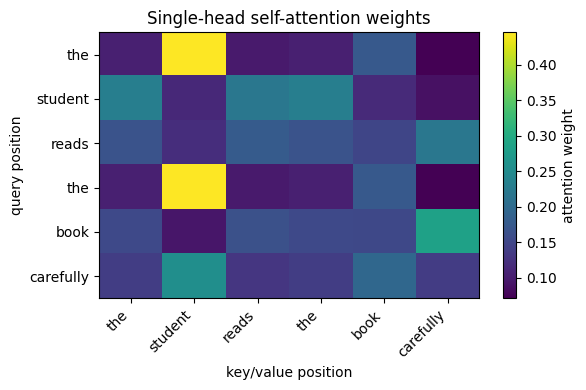

In [6]:
plt.figure(figsize=(6, 4))
plt.imshow(A, aspect="auto")
plt.xticks(range(len(sentence)), sentence, rotation=45, ha="right")
plt.yticks(range(len(sentence)), sentence)
plt.colorbar(label="attention weight")
plt.title("Single-head self-attention weights")
plt.xlabel("key/value position")
plt.ylabel("query position")
plt.tight_layout()
plt.show()

### Reflection

Choose one row of the heatmap. Which token position is asking the question? Which token positions are being used to answer it?

Attention weights are useful diagnostics, but they are not complete explanations of a model. The value vectors and later layers also matter.

## 6. Contextual embeddings and a first limitation

Self-attention output vectors depend on the whole sequence through the attention weights and value vectors. However, without positional information, two identical token rows inside the same sequence produce identical query rows, identical attention rows, and identical outputs.

This is not a bug. It is an important reason Transformers add positional information.

In this section, we first verify the limitation. Later, after adding positional encodings, the two occurrences of **the** will become distinguishable.

In [7]:
pos_the = [i for i, w in enumerate(sentence) if w == "the"]
print("Positions of 'the':", pos_the)
print("Input vectors equal before positional encoding?", np.allclose(X[pos_the[0]], X[pos_the[1]]))
print("Output vectors equal before positional encoding?", np.allclose(Z[pos_the[0]], Z[pos_the[1]]))
print("Output distance before positional encoding:", np.linalg.norm(Z[pos_the[0]] - Z[pos_the[1]]))

input_table = pd.DataFrame(
    np.vstack([X[pos_the[0]], X[pos_the[1]]]),
    index=["input the position 0", "input the position 3"],
    columns=[f"input_feature_{j}" for j in range(X.shape[1])]
)

output_table = pd.DataFrame(
    np.vstack([Z[pos_the[0]], Z[pos_the[1]]]),
    index=["output the position 0", "output the position 3"],
    columns=[f"output_feature_{j}" for j in range(Z.shape[1])]
)

display(input_table)
display(output_table)


Positions of 'the': [0, 3]
Input vectors equal before positional encoding? True
Output vectors equal before positional encoding? True
Output distance before positional encoding: 0.0


,input_feature_0,input_feature_1,input_feature_2,input_feature_3,input_feature_4
input the position 0,1.0,0.05,0.0,0.0,0.0
input the position 3,1.0,0.05,0.0,0.0,0.0


,output_feature_0,output_feature_1,output_feature_2,output_feature_3
output the position 0,-0.481328,0.582272,-0.484792,-0.191834
output the position 3,-0.481328,0.582272,-0.484792,-0.191834


### Why this matters

A word embedding table assigns the same vector to the same token type every time. Self-attention can use surrounding tokens, but without positions it is still symmetric with respect to row permutations. Positional encodings are what allow the model to distinguish the first **the** from the second **the** in the same sentence.

## 7. Permutation equivariance without positional information

Without positional encodings, self-attention does not know the original order of tokens. If we permute the input rows of $X$, the output rows are permuted in the same way.

Mathematically, let $P$ be a permutation matrix. Then single-head self-attention without positional information satisfies

$$
\operatorname{SelfAttn}(PX) = P\operatorname{SelfAttn}(X).
$$

This property is called **permutation equivariance**.

In [8]:
def permutation_matrix(order):
    T = len(order)
    P = np.zeros((T, T))
    for new_i, old_i in enumerate(order):
        P[new_i, old_i] = 1.0
    return P

order = [2, 0, 1, 5, 3, 4]
P = permutation_matrix(order)
X_perm = P @ X

Z_perm, A_perm, *_ = self_attention(X_perm, W_Q, W_K, W_V)
Z_expected = P @ Z

print("Permutation equivariance error:", np.linalg.norm(Z_perm - Z_expected))
print("Original tokens: ", sentence)
print("Permuted tokens:", [sentence[i] for i in order])

Permutation equivariance error: 2.8441001681421824e-16
Original tokens:  ['the', 'student', 'reads', 'the', 'book', 'carefully']
Permuted tokens: ['reads', 'the', 'student', 'carefully', 'the', 'book']


### Interpretation

The error should be close to zero up to floating-point rounding. This is a strength for sets and graphs, but a problem for language: **word order matters**.

## 8. Adding positional encodings

To represent order, Transformer models add positional information to token embeddings.

Here we use a simple deterministic sinusoidal positional encoding. For position $i$ and feature pair $2j, 2j+1$, define

$$
p_{i,2j} = \sin\left(i / 10000^{2j/d_{	ext{model}}}ight),
\qquad
p_{i,2j+1} = \cos\left(i / 10000^{2j/d_{	ext{model}}}ight).
$$

This is not the only choice, but it is a classic one.

In [9]:
def sinusoidal_positions(T, d_model):
    P = np.zeros((T, d_model))
    positions = np.arange(T)[:, None]
    even_dims = np.arange(0, d_model, 2)
    div_terms = np.exp(-np.log(10000.0) * even_dims / d_model)
    P[:, 0::2] = np.sin(positions * div_terms)
    if d_model > 1:
        P[:, 1::2] = np.cos(positions * div_terms[:P[:, 1::2].shape[1]])
    return P

P_pos = sinusoidal_positions(T=len(sentence), d_model=d_model)
X_with_pos = X + 0.25 * P_pos

pd.DataFrame(P_pos, index=[f"pos {i}" for i in range(len(sentence))])

,0,1,2,3,4
pos 0,0.000000,1.000000,0.000000,1.000000,0.000000
pos 1,0.841471,0.540302,0.025116,0.999685,0.000631
pos 2,0.909297,-0.416147,0.050217,0.998738,0.001262
pos 3,0.141120,-0.989992,0.075285,0.997162,0.001893
pos 4,-0.756802,-0.653644,0.100306,0.994957,0.002524
pos 5,-0.958924,0.283662,0.125264,0.992123,0.003155


In [10]:
Z_pos, A_pos, *_ = self_attention(X_with_pos, W_Q, W_K, W_V)

pos_the = [i for i, w in enumerate(sentence) if w == "the"]
print("Input vectors for the two 'the' tokens equal after positional encoding?", np.allclose(X_with_pos[pos_the[0]], X_with_pos[pos_the[1]]))
print("Distance between positional input vectors:", np.linalg.norm(X_with_pos[pos_the[0]] - X_with_pos[pos_the[1]]))
print("Distance between contextual output vectors:", np.linalg.norm(Z_pos[pos_the[0]] - Z_pos[pos_the[1]]))

Input vectors for the two 'the' tokens equal after positional encoding? False
Distance between positional input vectors: 0.49910322739556295
Distance between contextual output vectors: 0.04071419328074876


### Test: permutation equivariance is no longer automatic

If positional vectors are tied to absolute positions, permuting token embeddings while keeping the same position vectors changes the computation in a way that is not just a row permutation.

In [11]:
# Permute only the token embeddings, then add the original position vectors for positions 0,...,T-1.
X_token_perm_same_positions = X_perm + 0.25 * P_pos
Z_token_perm_pos, *_ = self_attention(X_token_perm_same_positions, W_Q, W_K, W_V)

print("Error if tokens are permuted but absolute positions stay fixed:", np.linalg.norm(Z_token_perm_pos - P @ Z_pos))

Error if tokens are permuted but absolute positions stay fixed: 0.3359644598214728


## 9. Padding masks

In minibatch training, sentences often have different lengths. We pad shorter sequences to a common length, but padded positions should not be attended to.

A padding mask blocks columns corresponding to padding tokens. In additive form, allowed positions receive $0$ and blocked positions receive a large negative number.

In [12]:
padded_sentence = ["the", "student", "reads", "<PAD>", "<PAD>"]
valid = np.array([1, 1, 1, 0, 0], dtype=bool)

# Reuse embeddings for real tokens and assign zero vector to PAD.
X_pad = np.zeros((len(padded_sentence), d_model))
for i, tok in enumerate(padded_sentence):
    if tok != "<PAD>":
        X_pad[i] = E[token_to_id[tok]]

T_pad = len(padded_sentence)
padding_mask = np.zeros((T_pad, T_pad))
padding_mask[:, ~valid] = -1e9

Z_pad, A_pad, S_pad, *_ = self_attention(X_pad, W_Q, W_K, W_V, mask=padding_mask)

pd.DataFrame(A_pad, index=padded_sentence, columns=padded_sentence)

,the,student,reads,<PAD>,<PAD>
the,0.161006,0.687007,0.151987,0.0,0.0
student,0.408700,0.201754,0.389546,0.0,0.0
reads,0.357093,0.258018,0.384889,0.0,0.0
<PAD>,0.333333,0.333333,0.333333,0.0,0.0
<PAD>,0.333333,0.333333,0.333333,0.0,0.0


In [13]:
print("Attention mass assigned to PAD columns:", A_pad[:, ~valid].sum())
print("Row sums:", A_pad.sum(axis=1))

Attention mass assigned to PAD columns: 0.0
Row sums: [1. 1. 1. 1. 1.]


### Important detail

The padding mask above blocks attention **to** padded keys and values. In real models, one often also masks or ignores loss contributions **from** padded query positions.

## 10. Causal masks

For autoregressive language modeling, token position $i$ must not attend to future positions $j>i$. A causal mask blocks the strict upper triangle of the score matrix.

In [14]:
def causal_mask(T):
    M = np.zeros((T, T))
    M[np.triu_indices(T, k=1)] = -1e9
    return M

M_causal = causal_mask(len(sentence))
Z_causal, A_causal, *_ = self_attention(X_with_pos, W_Q, W_K, W_V, mask=M_causal)

pd.DataFrame(A_causal, index=sentence, columns=sentence)

,the,student,reads,the,book,carefully
the,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000
student,0.563616,0.436384,0.000000,0.000000,0.000000,0.00000
reads,0.310962,0.390517,0.298521,0.000000,0.000000,0.00000
the,0.147220,0.707088,0.073430,0.072262,0.000000,0.00000
book,0.182849,0.120881,0.232899,0.227469,0.235902,0.00000
carefully,0.160001,0.217789,0.131386,0.141871,0.192873,0.15608


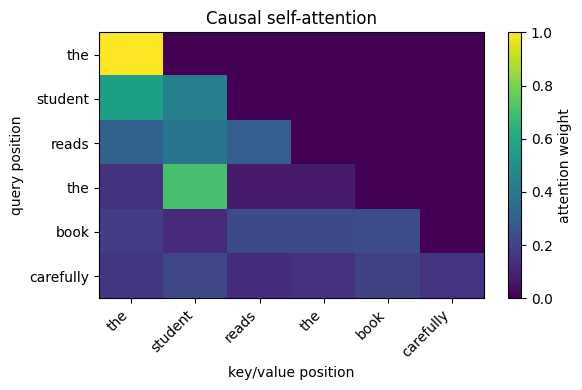

Total attention mass on future positions: 0.0


In [15]:
plt.figure(figsize=(6, 4))
plt.imshow(A_causal, aspect="auto")
plt.xticks(range(len(sentence)), sentence, rotation=45, ha="right")
plt.yticks(range(len(sentence)), sentence)
plt.colorbar(label="attention weight")
plt.title("Causal self-attention")
plt.xlabel("key/value position")
plt.ylabel("query position")
plt.tight_layout()
plt.show()

future_mass = A_causal[np.triu_indices(len(sentence), k=1)].sum()
print("Total attention mass on future positions:", future_mass)

### Reflection

Why is the first row forced to attend only to itself? Why can the final row attend to every previous position?

## 11. Attention entropy

For one attention row $a$, the entropy is

$$
H(a) = -\sum_j a_j \log(a_j).
$$

Small entropy means sharp attention. Large entropy means diffuse attention.

In [16]:
def entropy_rows(A, eps=1e-12):
    A_safe = np.clip(A, eps, 1.0)
    return -(A_safe * np.log(A_safe)).sum(axis=1)

entropy_plain = entropy_rows(A)
entropy_causal = entropy_rows(A_causal)

pd.DataFrame({
    "token": sentence,
    "entropy_unmasked": entropy_plain,
    "entropy_causal": entropy_causal
})

,token,entropy_unmasked,entropy_causal
0,the,1.553777,1.381551e-10
1,student,1.721515,6.850313e-01
2,reads,1.775632,1.091313e+00
3,the,1.553777,9.087467e-01
4,book,1.735762,1.583007e+00
5,carefully,1.756794,1.776205e+00


### Temperature and score scaling

If we multiply the scores by a larger constant before softmax, the attention tends to become sharper. If we divide the scores, the attention tends to become more uniform.

In [17]:
def attention_from_scores(S, temperature=1.0):
    return row_softmax(S / temperature)

temperatures = [0.25, 0.5, 1.0, 2.0, 5.0]
rows = []
for tau in temperatures:
    A_tau = attention_from_scores(S, temperature=tau)
    rows.append({
        "temperature": tau,
        "mean_entropy": entropy_rows(A_tau).mean(),
        "max_weight_mean": A_tau.max(axis=1).mean()
    })

pd.DataFrame(rows)

,temperature,mean_entropy,max_weight_mean
0,0.25,0.896780,0.669919
1,0.50,1.391438,0.476299
2,1.00,1.682876,0.313972
3,2.00,1.766378,0.233099
4,5.00,1.787983,0.191126


## 12. Multi-head self-attention

A single head uses one comparison geometry. Multi-head attention uses several heads in parallel. Each head has its own $W_Q$, $W_K$, and $W_V$.

The head outputs are concatenated:

$$
Z_{	ext{multi}} = [Z^{(1)} \; Z^{(2)} \; \cdots \; Z^{(h)}].
$$

A full Transformer layer usually follows this with an output projection, residual connection, normalization, and feed-forward network. In this lab, we focus only on the attention block.

In [18]:
def multi_head_self_attention(X, heads, mask=None):
    """Compute multi-head self-attention by concatenating head outputs."""
    outputs = []
    attentions = []
    for WQ, WK, WV in heads:
        Z_h, A_h, *_ = self_attention(X, WQ, WK, WV, mask=mask)
        outputs.append(Z_h)
        attentions.append(A_h)
    return np.concatenate(outputs, axis=1), attentions

num_heads = 3
heads = []
for _ in range(num_heads):
    WQ = rng.normal(0, 0.6, size=(d_model, 2))
    WK = rng.normal(0, 0.6, size=(d_model, 2))
    WV = rng.normal(0, 0.6, size=(d_model, 3))
    heads.append((WQ, WK, WV))

Z_multi, A_heads = multi_head_self_attention(X_with_pos, heads)
print("Input shape:", X_with_pos.shape)
print("Multi-head output shape:", Z_multi.shape)
for h, A_h in enumerate(A_heads, start=1):
    print(f"Head {h}: attention shape {A_h.shape}, mean entropy {entropy_rows(A_h).mean():.3f}")

Input shape: (6, 5)
Multi-head output shape: (6, 9)
Head 1: attention shape (6, 6), mean entropy 1.766
Head 2: attention shape (6, 6), mean entropy 1.773
Head 3: attention shape (6, 6), mean entropy 1.744


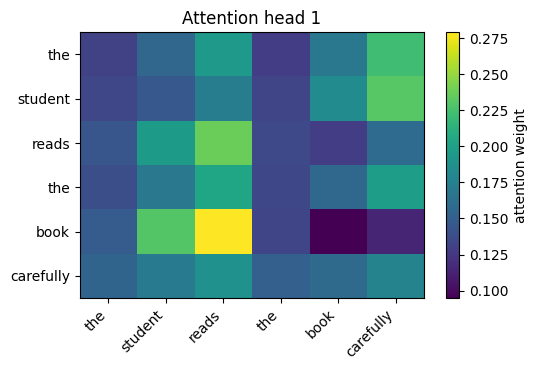

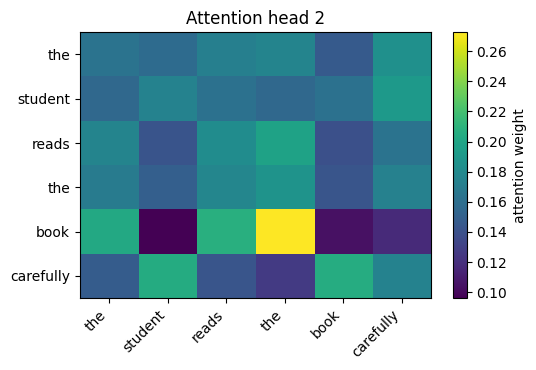

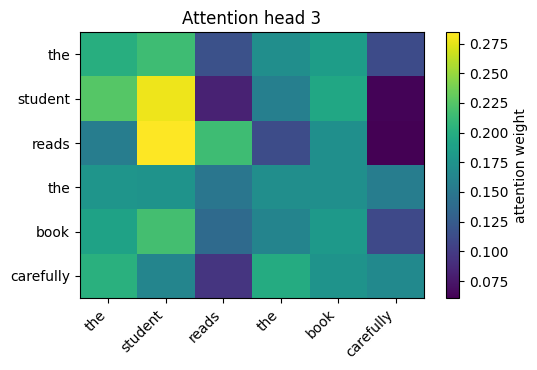

In [19]:
for h, A_h in enumerate(A_heads, start=1):
    plt.figure(figsize=(5.5, 3.8))
    plt.imshow(A_h, aspect="auto")
    plt.xticks(range(len(sentence)), sentence, rotation=45, ha="right")
    plt.yticks(range(len(sentence)), sentence)
    plt.colorbar(label="attention weight")
    plt.title(f"Attention head {h}")
    plt.tight_layout()
    plt.show()

### Reflection

Do the heads attend in the same way? If not, this illustrates why multi-head attention can represent several relation types in parallel.

## 13. Self-attention as a learned graph

The attention matrix $A$ can be viewed as a weighted directed graph on token positions. Each row is outgoing mass from a query position to key/value positions.

One simple diagnostic is to list the top attended token for each query token.

In [20]:
def top_attention_table(A, tokens, k=2):
    rows = []
    for i, tok in enumerate(tokens):
        top = np.argsort(-A[i])[:k]
        rows.append({
            "query_position": i,
            "query_token": tok,
            "top_keys": ", ".join([f"{tokens[j]}:{A[i,j]:.3f}" for j in top])
        })
    return pd.DataFrame(rows)

top_attention_table(A_pos, sentence, k=2)

,query_position,query_token,top_keys
0,0,the,"student:0.485, book:0.150"
1,1,student,"the:0.228, reads:0.211"
2,2,reads,"carefully:0.200, student:0.192"
3,3,the,"student:0.535, book:0.158"
4,4,book,"carefully:0.309, book:0.163"
5,5,carefully,"student:0.218, book:0.193"


## 14. Computational cost

For a sequence length $T$, the score matrix $S=QK^T$ has shape $T 	imes T$. Therefore the memory used by the attention matrix grows like $T^2$.

This quadratic cost is one of the main limitations of standard self-attention for very long documents.

In [21]:
lengths = np.array([16, 32, 64, 128, 256, 512, 1024, 2048])
entries = lengths ** 2
memory_float32_mb = entries * 4 / (1024 ** 2)

cost_df = pd.DataFrame({
    "T": lengths,
    "attention_entries_T_squared": entries,
    "float32_memory_MB_for_one_attention_matrix": memory_float32_mb
})
cost_df

,T,attention_entries_T_squared,float32_memory_MB_for_one_attention_matrix
0,16,256,0.000977
1,32,1024,0.003906
2,64,4096,0.015625
3,128,16384,0.062500
4,256,65536,0.250000
5,512,262144,1.000000
6,1024,1048576,4.000000
7,2048,4194304,16.000000


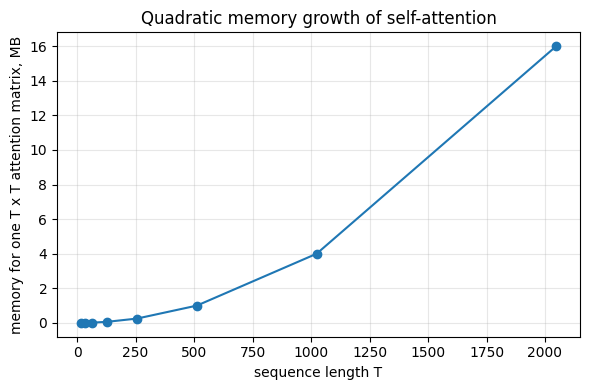

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(lengths, memory_float32_mb, marker="o")
plt.xlabel("sequence length T")
plt.ylabel("memory for one T x T attention matrix, MB")
plt.title("Quadratic memory growth of self-attention")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The plot shows memory for only one attention matrix in one layer and one batch element. Real Transformer models have many heads, many layers, and many examples per batch.

## 15. A small order-sensitivity experiment

We compare two sentences with the same words but different order:

1. `student reads book carefully`
2. `book reads student carefully`

The second sentence is strange, but bag-of-words representations treat the word counts as the same. Self-attention with positional information can distinguish them.

In [23]:
s1 = ["student", "reads", "book", "carefully"]
s2 = ["book", "reads", "student", "carefully"]

def embed_sentence(tokens, use_pos=True, scale=0.25):
    X_tok = E[[token_to_id[t] for t in tokens]]
    if use_pos:
        return X_tok + scale * sinusoidal_positions(len(tokens), d_model)
    return X_tok

X1_bow_like = embed_sentence(s1, use_pos=False)
X2_bow_like = embed_sentence(s2, use_pos=False)
X1_pos = embed_sentence(s1, use_pos=True)
X2_pos = embed_sentence(s2, use_pos=True)

Z1_no_pos, *_ = self_attention(X1_bow_like, W_Q, W_K, W_V)
Z2_no_pos, *_ = self_attention(X2_bow_like, W_Q, W_K, W_V)
Z1_pos, *_ = self_attention(X1_pos, W_Q, W_K, W_V)
Z2_pos, *_ = self_attention(X2_pos, W_Q, W_K, W_V)

# Compare sentence-level pooled representations.
pool = lambda Z: Z.mean(axis=0)
print("Pooled distance without positional information:", np.linalg.norm(pool(Z1_no_pos) - pool(Z2_no_pos)))
print("Pooled distance with positional information:", np.linalg.norm(pool(Z1_pos) - pool(Z2_pos)))

Pooled distance without positional information: 6.206335383118183e-17
Pooled distance with positional information: 0.023425644094903858


### Reflection

Why does mean pooling after a permutation-equivariant layer still fail to distinguish word order when there is no positional information?

## 16. Exercises

Complete these exercises by modifying or extending the code above.

### Exercise 1: dimension audit

Change $d_k$ and $d_v$. Verify the shapes of $Q$, $K$, $V$, $S$, $A$, and $Z$. Explain which dimensions depend on sequence length and which depend on projection size.

### Exercise 2: context test

Create a sentence with the same word appearing in three different locations. Compute the pairwise distances among the three contextual output vectors.

### Exercise 3: mask construction

Write a function that combines a padding mask and a causal mask. Test it on a padded sequence used in autoregressive language modeling.

### Exercise 4: entropy comparison

For each attention head in the multi-head example, compute the entropy of each row. Which head is sharpest on average?

### Exercise 5: positional scale

Change the positional encoding scale from $0$ to $1$. Plot how the distance between the two contextual representations of **the** changes.

## 17. AI-assisted learning prompts

Use these prompts with an AI assistant only after you have tried the calculations yourself.

### Prompt 1: dimension audit

> I implemented self-attention with $X \in R^{T 	imes d_{	ext{model}}}$, $W_Q,W_K \in R^{d_{	ext{model}} 	imes d_k}$, and $W_V \in R^{d_{	ext{model}} 	imes d_v}$. Check the dimensions of every intermediate matrix and explain any possible mistakes.

### Prompt 2: permutation equivariance

> Explain why self-attention without positional encoding is permutation equivariant. Give a short matrix proof using a permutation matrix $P$.

### Prompt 3: masking

> Explain the difference between a padding mask and a causal mask in self-attention. Give a small $5 	imes 5$ example of each.

### Prompt 4: interpretability caution

> Why should attention heatmaps be interpreted carefully? Explain what they show and what they do not show.

## 18. Mini-project: attention pattern laboratory

Design your own small attention experiment.

Choose one of the following projects.

### Project A: repeated words

Create sentences with repeated words, such as:

- `the student reads the book`
- `the teacher writes the notes`
- `the book helps the student`

Study how the contextual representations of repeated words change with and without positional encodings.

### Project B: mask laboratory

Build several masks:

1. no mask;
2. causal mask;
3. padding mask;
4. combined causal and padding mask.

Visualize the resulting attention matrices and explain the allowed and blocked regions.

### Project C: head diversity

Generate 5 to 10 random attention heads. For each head, compute:

- mean row entropy;
- average maximum attention weight;
- top attended token per query.

Discuss whether different heads specialize in different token relations.

Your final mini-project report should include at least one heatmap, one table, and one paragraph connecting your observations to the mathematics of self-attention.

## 19. What to remember

Self-attention is a matrix-valued operation that builds contextual token representations.

Key points:

1. Self-attention uses $Q=XW_Q$, $K=XW_K$, and $V=XW_V$.
2. The matrix $QK^T$ compares all token positions with all token positions.
3. The row-wise softmax makes each row of attention a probability distribution.
4. The output $Z=AV$ contains contextual embeddings.
5. Without positional information, self-attention is permutation equivariant.
6. Positional encodings are needed for word order.
7. Padding masks block padded tokens; causal masks block future tokens.
8. Multi-head attention runs several attention heads in parallel.
9. Standard self-attention has quadratic cost in the sequence length $T$.